# Statistical Tests, P-values & A/B Testing
## AI Bootcamp - 1 Hour Session

## Learning Objectives

By the end of this session, you will be able to:

- **Understand** what statistical tests are and when to use them
- **Interpret** P-values and their significance
- **Design and analyze** A/B tests
- **Apply** these concepts in AI/ML contexts
- **Use Python** to perform statistical testing

---

## What are Statistical Tests?

**Statistical tests help us make decisions about data**

- **Purpose**: Determine if observed differences are real or due to chance
- **Applications in AI/ML**:
  - Model performance comparison
  - Feature importance validation
  - Dataset quality assessment
  - A/B testing for ML systems

**Key Question**: "Is this difference significant or just random?"

---

## The Logic of Statistical Testing

**Hypothesis Testing Framework**:

1. **Null Hypothesis (H₀)**: "No difference exists"
2. **Alternative Hypothesis (H₁)**: "A difference exists"
3. **Collect Evidence**: Gather data and calculate test statistic
4. **Make Decision**: Accept or reject H₀ based on evidence strength

**Example**: Does our new ML model perform better than the old one?
- H₀: New model accuracy = Old model accuracy
- H₁: New model accuracy ≠ Old model accuracy

---

## Understanding P-values

**P-value Definition**: 
*The probability of observing results at least as extreme as those observed, assuming the null hypothesis is true*

**Interpretation Guide**:
- **P < 0.05**: Strong evidence against H₀ (statistically significant)
- **P < 0.01**: Very strong evidence against H₀
- **P ≥ 0.05**: Insufficient evidence to reject H₀

**Common Misconception**: P-value ≠ probability that H₀ is true

---

## Common Statistical Tests

**T-test**: Compare means between groups
- One-sample: Compare sample mean to known value
- Two-sample: Compare means of two groups
- Paired: Compare before/after measurements

**Chi-square**: Test relationships between categorical variables

**ANOVA**: Compare means across multiple groups

**Mann-Whitney U**: Non-parametric alternative to t-test

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.power import ttest_power
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [3]:
print("\n🎯 SECTION 1: Understanding P-values with Simulation")
print("-" * 50)

# Simulate coin flipping experiment
np.random.seed(42)

def simulate_coin_flips(n_flips=100, true_prob=0.5, n_simulations=1000):
    """Simulate coin flipping to understand p-values"""
    results = []
    
    for i in range(n_simulations):
        # Simulate coin flips
        flips = np.random.binomial(n_flips, true_prob)
        
        # Perform binomial test (H0: p = 0.5)
        test_res = stats.binomtest(flips, n_flips, 0.5, alternative='two-sided')
        
        p_value = test_res.pvalue
        statistics = test_res.statistic
        
        results.append({
            'simulation': i,
            'heads': flips,
            'proportion': flips/n_flips,
            'p_value': p_value,
            'significant': p_value < 0.05
        })
    
    return pd.DataFrame(results)

# Run simulation
coin_results = simulate_coin_flips()
display(coin_results)
print(f"Out of 1000 simulations with a fair coin:")
print(f"• {sum(coin_results['significant'])} tests were significant (p < 0.05)")
print(f"• That's {sum(coin_results['significant'])/10:.1f}% - close to expected 5%!")


🎯 SECTION 1: Understanding P-values with Simulation
--------------------------------------------------


,simulation,heads,proportion,p_value,significant
0,0,49,0.49,0.920411,False
1,1,52,0.52,0.764353,False
2,2,44,0.44,0.271253,False
3,3,42,0.42,0.133211,False
4,4,58,0.58,0.133211,False
...,...,...,...,...,...
995,995,47,0.47,0.617299,False
996,996,46,0.46,0.484118,False
997,997,45,0.45,0.368202,False
998,998,50,0.50,1.000000,False


Out of 1000 simulations with a fair coin:
• 24 tests were significant (p < 0.05)
• That's 2.4% - close to expected 5%!


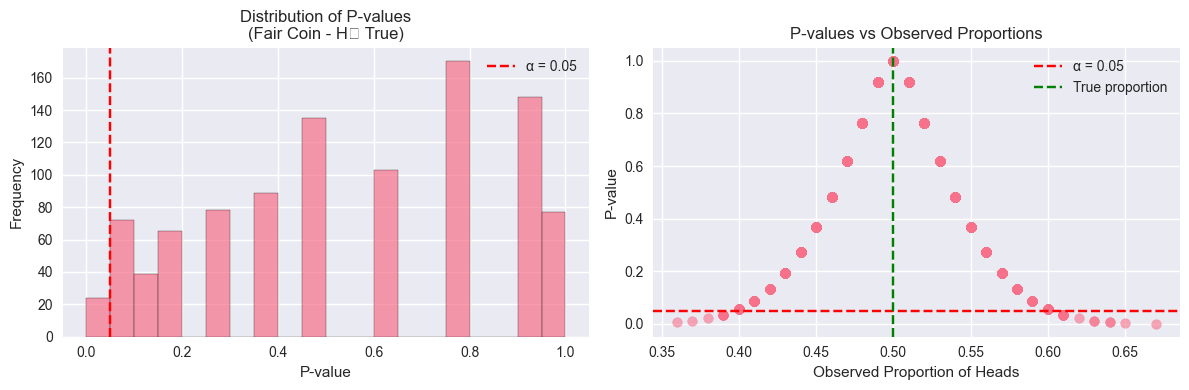

In [4]:
# Visualize p-value distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(coin_results['p_value'], bins=20, alpha=0.7, edgecolor='black')
plt.axvline(0.05, color='red', linestyle='--', label='α = 0.05')
plt.xlabel('P-value')
plt.ylabel('Frequency')
plt.title('Distribution of P-values\n(Fair Coin - H₀ True)')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(coin_results['proportion'], coin_results['p_value'], alpha=0.6)
plt.axhline(0.05, color='red', linestyle='--', label='α = 0.05')
plt.axvline(0.5, color='green', linestyle='--', label='True proportion')
plt.xlabel('Observed Proportion of Heads')
plt.ylabel('P-value')
plt.title('P-values vs Observed Proportions')
plt.legend()

plt.tight_layout()
plt.show()

# =============================================================================
# SECTION 2: COMPARING ML MODEL PERFORMANCE
# =============================================================================

In [10]:
print("\n🤖 SECTION 2: Comparing ML Model Performance")
print("-" * 50)

# Simulate model accuracy data
np.random.seed(42)

# Model A (current model) - slightly lower performance
model_a_accuracy = np.random.normal(0.82, 0.05, 100)  # mean=82%, std=5%

# Model B (new model) - slightly higher performance  
model_b_accuracy = np.random.normal(0.85, 0.05, 100)  # mean=85%, std=5%

# Ensure accuracies are between 0 and 1
model_a_accuracy = np.clip(model_a_accuracy, 0, 1)
model_b_accuracy = np.clip(model_b_accuracy, 0, 1)

# Create DataFrame
model_comparison = pd.DataFrame({
    'Model_A': model_a_accuracy,
    'Model_B': model_b_accuracy
})

print("Model Performance Summary:")
print(model_comparison.describe())

# Perform statistical tests
def compare_models(model_a, model_b, alpha=0.05):
    """Compare two models using multiple statistical tests"""
    
    results = {}
    
    # 1. Two-sample t-test (assuming normality)
    t_stat, t_p = stats.ttest_ind(model_a, model_b)
    results['t_test'] = {'statistic': t_stat, 'p_value': t_p}
    
    # 2. Mann-Whitney U test (non-parametric)
    u_stat, u_p = stats.mannwhitneyu(model_a, model_b, alternative='two-sided')
    results['mann_whitney'] = {'statistic': u_stat, 'p_value': u_p}
    
    # 3. Kolmogorov-Smirnov test
    ks_stat, ks_p = stats.ks_2samp(model_a, model_b)
    results['ks_test'] = {'statistic': ks_stat, 'p_value': ks_p}
    
    # Effect size (Cohen's d)
    pooled_std = np.sqrt(((len(model_a)-1)*np.var(model_a) + 
                         (len(model_b)-1)*np.var(model_b)) / 
                        (len(model_a) + len(model_b) - 2))
    cohens_d = (np.mean(model_b) - np.mean(model_a)) / pooled_std
    results['effect_size'] = cohens_d
    
    return results

# Compare models
comparison_results = compare_models(model_a_accuracy, model_b_accuracy)

print(f"\n📈 Statistical Comparison Results:")
print(f"Model A mean accuracy: {np.mean(model_a_accuracy):.4f}")
print(f"Model B mean accuracy: {np.mean(model_b_accuracy):.4f}")
print(f"Difference: {np.mean(model_b_accuracy) - np.mean(model_a_accuracy):.4f}")

print(f"\nTest Results:")
for test_name, result in comparison_results.items():
    if test_name != 'effect_size':
        p_val = result['p_value']
        significance = "✅ Significant" if p_val < 0.05 else "❌ Not Significant"
        print(f"• {test_name.title()}: p = {p_val:.4f} ({significance})")

print(f"• Effect Size (Cohen's d): {comparison_results['effect_size']:.4f}")




🤖 SECTION 2: Comparing ML Model Performance
--------------------------------------------------
Model Performance Summary:
          Model_A     Model_B
count  100.000000  100.000000
mean     0.814808    0.851115
std      0.045408    0.047683
min      0.689013    0.754061
25%      0.789955    0.809717
50%      0.813652    0.854205
75%      0.840298    0.876909
max      0.912614    0.986008

📈 Statistical Comparison Results:
Model A mean accuracy: 0.8148
Model B mean accuracy: 0.8511
Difference: 0.0363

Test Results:
• T_Test: p = 0.0000 (✅ Significant)
• Mann_Whitney: p = 0.0000 (✅ Significant)
• Ks_Test: p = 0.0000 (✅ Significant)
• Effect Size (Cohen's d): 0.7837


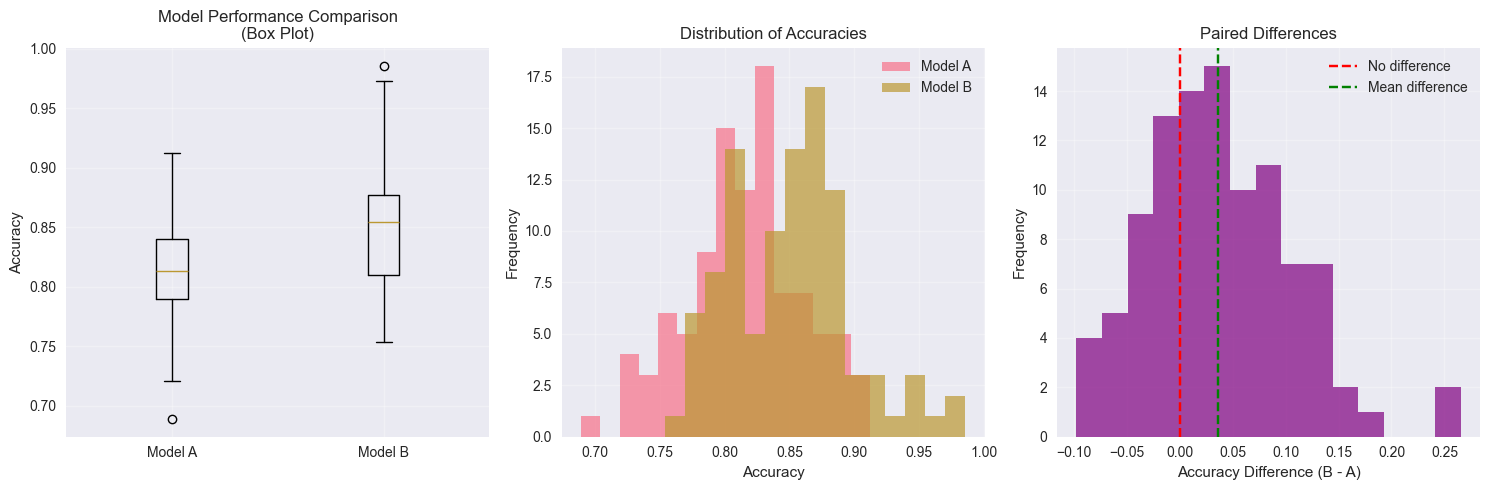

In [11]:
# Visualize model comparison
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.boxplot([model_a_accuracy, model_b_accuracy], labels=['Model A', 'Model B'])
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison\n(Box Plot)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.hist(model_a_accuracy, alpha=0.7, label='Model A', bins=15)
plt.hist(model_b_accuracy, alpha=0.7, label='Model B', bins=15)
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.title('Distribution of Accuracies')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
diff_scores = model_b_accuracy - model_a_accuracy
plt.hist(diff_scores, bins=15, alpha=0.7, color='purple')
plt.axvline(0, color='red', linestyle='--', label='No difference')
plt.axvline(np.mean(diff_scores), color='green', linestyle='--', label='Mean difference')
plt.xlabel('Accuracy Difference (B - A)')
plt.ylabel('Frequency')
plt.title('Paired Differences')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Introduction to A/B Testing

**A/B Testing**: Controlled experiment comparing two versions

**Why A/B Test in AI/ML?**
- **Model Deployment**: New vs. current model performance
- **Feature Engineering**: Impact of new features
- **Algorithm Selection**: Compare different approaches
- **User Experience**: ML-driven recommendations or predictions

**Real Example**: Testing two recommendation algorithms on user engagement

---

## A/B Testing Process

**1. Design Phase**
- Define hypothesis and success metrics
- Determine sample size and test duration
- Random assignment to groups

**2. Implementation Phase**
- Split traffic/users randomly (50/50 or other ratios)
- Ensure proper isolation between groups
- Monitor for technical issues

**3. Analysis Phase**
- Calculate test statistics
- Interpret P-values and confidence intervals
- Make data-driven decisions

---

## A/B Testing: Key Concepts

**Control Group (A)**: Current version/baseline
**Treatment Group (B)**: New version being tested

**Success Metrics Examples**:
- Model accuracy/precision/recall
- User engagement rates
- Conversion rates
- Response time

**Statistical Power**: Ability to detect a true effect
**Effect Size**: Magnitude of the difference

---

## A/B Testing Best Practices

**Design Considerations**:
- ✅ Random assignment is crucial
- ✅ Sufficient sample size (power analysis)
- ✅ Single primary metric focus
- ✅ Pre-define stopping criteria

**Common Pitfalls**:
- ❌ Peeking at results too early
- ❌ Multiple testing without correction
- ❌ Insufficient sample size
- ❌ Selection bias in group assignment

---

In [12]:
class ABTest:
    """A/B Testing Class for conversion rate experiments"""
    
    def __init__(self, name):
        self.name = name
        self.results = {}
    
    def run_experiment(self, control_rate, treatment_rate, sample_size_per_group):
        """Run A/B test simulation"""
        np.random.seed(42)
        
        # Generate conversion data
        control_conversions = np.random.binomial(sample_size_per_group, control_rate)
        treatment_conversions = np.random.binomial(sample_size_per_group, treatment_rate)
        
        # Store results
        self.results = {
            'control_conversions': control_conversions,
            'treatment_conversions': treatment_conversions,
            'control_size': sample_size_per_group,
            'treatment_size': sample_size_per_group,
            'control_rate': control_conversions / sample_size_per_group,
            'treatment_rate': treatment_conversions / sample_size_per_group
        }
        
        return self.results
    
    def analyze_results(self, alpha=0.05):
        """Analyze A/B test results"""
        if not self.results:
            return "No experiment data. Run experiment first."
        
        # Extract data
        control_conv = self.results['control_conversions']
        treatment_conv = self.results['treatment_conversions']
        control_n = self.results['control_size']
        treatment_n = self.results['treatment_size']
        
        # Z-test for proportions
        counts = np.array([treatment_conv, control_conv])
        nobs = np.array([treatment_n, control_n])
        
        z_stat, p_value = proportions_ztest(counts, nobs)
        
        # Confidence intervals
        control_ci = proportion_confint(control_conv, control_n, alpha=alpha)
        treatment_ci = proportion_confint(treatment_conv, treatment_n, alpha=alpha)
        
        # Effect size (relative improvement)
        relative_improvement = ((self.results['treatment_rate'] - 
                               self.results['control_rate']) / 
                              self.results['control_rate']) * 100
        
        analysis = {
            'control_rate': self.results['control_rate'],
            'treatment_rate': self.results['treatment_rate'],
            'absolute_difference': self.results['treatment_rate'] - self.results['control_rate'],
            'relative_improvement': relative_improvement,
            'z_statistic': z_stat,
            'p_value': p_value,
            'significant': p_value < alpha,
            'control_ci': control_ci,
            'treatment_ci': treatment_ci
        }
        
        return analysis

In [13]:
# Example 1: Email Campaign A/B Test
email_test = ABTest("Email Campaign Optimization")

print("🎯 Email Campaign A/B Test Example")
print("Scenario: Testing subject line impact on open rates")
print("• Control: Standard subject line")
print("• Treatment: Personalized subject line")

# Run experiment
email_results = email_test.run_experiment(
    control_rate=0.12,      # 12% open rate
    treatment_rate=0.15,    # 15% open rate  
    sample_size_per_group=1000
)

# Analyze results
email_analysis = email_test.analyze_results()

print(f"\n📊 Results:")
print(f"• Control open rate: {email_analysis['control_rate']:.3f} ({email_analysis['control_rate']*100:.1f}%)")
print(f"• Treatment open rate: {email_analysis['treatment_rate']:.3f} ({email_analysis['treatment_rate']*100:.1f}%)")
print(f"• Absolute difference: {email_analysis['absolute_difference']:.3f}")
print(f"• Relative improvement: {email_analysis['relative_improvement']:.1f}%")
print(f"• P-value: {email_analysis['p_value']:.4f}")
print(f"• Statistically significant: {'✅ Yes' if email_analysis['significant'] else '❌ No'}")

🎯 Email Campaign A/B Test Example
Scenario: Testing subject line impact on open rates
• Control: Standard subject line
• Treatment: Personalized subject line

📊 Results:
• Control open rate: 0.115 (11.5%)
• Treatment open rate: 0.152 (15.2%)
• Absolute difference: 0.037
• Relative improvement: 32.2%
• P-value: 0.0150
• Statistically significant: ✅ Yes


In [14]:
# Example 2: ML Model A/B Test
model_test = ABTest("ML Recommendation System")

print(f"\n🤖 ML Recommendation System A/B Test")
print("Scenario: Testing new recommendation algorithm")
print("• Control: Current algorithm")
print("• Treatment: New ML algorithm")

# Run experiment with smaller effect size
model_results = model_test.run_experiment(
    control_rate=0.08,      # 8% click-through rate
    treatment_rate=0.095,   # 9.5% click-through rate
    sample_size_per_group=2000
)

# Analyze results
model_analysis = model_test.analyze_results()

print(f"\n📊 Results:")
print(f"• Control CTR: {model_analysis['control_rate']:.4f} ({model_analysis['control_rate']*100:.1f}%)")
print(f"• Treatment CTR: {model_analysis['treatment_rate']:.4f} ({model_analysis['treatment_rate']*100:.1f}%)")
print(f"• Absolute difference: {model_analysis['absolute_difference']:.4f}")
print(f"• Relative improvement: {model_analysis['relative_improvement']:.1f}%")
print(f"• P-value: {model_analysis['p_value']:.4f}")
print(f"• Statistically significant: {'✅ Yes' if model_analysis['significant'] else '❌ No'}")


🤖 ML Recommendation System A/B Test
Scenario: Testing new recommendation algorithm
• Control: Current algorithm
• Treatment: New ML algorithm

📊 Results:
• Control CTR: 0.0765 (7.6%)
• Treatment CTR: 0.0920 (9.2%)
• Absolute difference: 0.0155
• Relative improvement: 20.3%
• P-value: 0.0776
• Statistically significant: ❌ No


## Statistical Significance vs Practical Significance

**Statistical Significance**: P < 0.05 (effect is unlikely due to chance)

**Practical Significance**: Effect size is meaningful in business context

**Example**: 
- New model has 0.1% higher accuracy (P < 0.01)
- Statistically significant but may not justify deployment costs
- Consider: computational cost, maintenance, complexity

**Always ask**: "Is this difference large enough to matter?"

## Python Tools for Statistical Testing

**Essential Libraries**:
```python
import scipy.stats as stats
import numpy as np
import pandas as pd
from statsmodels.stats.power import ttest_power
```

**Common Functions**:
- `stats.ttest_ind()`: Two-sample t-test
- `stats.chi2_contingency()`: Chi-square test
- `stats.mannwhitneyu()`: Mann-Whitney U test
- `ttest_power()`: Power analysis

---

## Hands-On Practice

**Let's Practice With**:

1. **Model Comparison**: Compare accuracy of two ML models
2. **A/B Test Analysis**: Analyze conversion rate experiment
3. **Power Analysis**: Calculate required sample sizes
4. **Real Dataset**: Apply tests to actual data

---

## Key Takeaways

**Remember**:
- Statistical tests help distinguish signal from noise
- P-values measure evidence strength, not effect importance
- A/B testing is crucial for validating AI/ML improvements
- Always consider both statistical and practical significance
- Proper experimental design prevents misleading conclusions